## Step 0 — Libraries

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU: False


## Step 1 — Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/Colab Notebooks'
print('Files:', sorted(os.listdir(FOLDER)))

Mounted at /content/drive
Files: ['CNN Cifar10.ipynb', 'CNN_models.ipynb', 'Copy of ECG Classification RNN | GRU | LSTM', 'Copy of NeurNetworks-Project-Part1.ipynb', 'Glycemie.ipynb', 'Human fall detection.ipynb', 'MCTNet_Arkansas_2021.csv', 'MCTNet_California_2021.csv', 'NeurNetworks_Part1.ipynb', 'NeurNetworks_Part1_GEE_fixed (weight decay=5e-2) (1).ipynb', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'crop_class_bekeras copy.ipynb', 'crop_classification_DL.ipynb', 'crop_classification_DL_enhanced.ipynb', 'crop_classification_keras (2).ipynb', 'crop_classification_keras (3).ipynb', 'crop_classification_keras (4).ipynb', 'crop_classification_keras (5).ipynb', 'crop_classification_keras (7).ipynb', 'crop_classification_keras (8).ipynb', 'crop_classification_keras(fin).ipynb', 'crop_classification_keras.ipynb', 'crop_classification_student.ipynb', 'crop_samples_arkansas.csv', 'crop_samples_california.csv', 'dataset_version2.csv', 'diabet

In [3]:
df_ar = pd.read_csv(os.path.join(FOLDER, 'MCTNet_Arkansas_2021.csv'))
df_ca = pd.read_csv(os.path.join(FOLDER, 'MCTNet_California_2021.csv'))

BANDS       = ['Blue', 'Green', 'NIR', 'RE1', 'RE2', 'RE3', 'RE4', 'Red', 'SWIR1', 'SWIR2']
N_TIMESTEPS = 36
N_BANDS     = 10

# Spectral columns in correct order: (t01,band0), (t01,band1),...,(t36,band9)
SPEC_COLS  = [f'{b}_t{t:02d}' for t in range(1, N_TIMESTEPS+1) for b in BANDS]
VALID_COLS = [f'valid_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]

# Label names — verified against paper Table 2 class counts
AR_LABELS = {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton', 4: 'Others'}
CA_LABELS = {0: 'Grapes', 1: 'Rice', 2: 'Alfalfa', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'}

print('Arkansas :', df_ar.shape)
print(df_ar['label'].value_counts().sort_index().rename(AR_LABELS))
print('\nCalifornia:', df_ca.shape)
print(df_ca['label'].value_counts().sort_index().rename(CA_LABELS))

Arkansas : (10000, 403)
label
Soybeans    4704
Rice        2488
Corn        1392
Cotton       806
Others       610
Name: count, dtype: int64

California: (10000, 403)
label
Grapes        2008
Rice          1856
Alfalfa        985
Almonds        808
Pistachios     585
Others        3758
Name: count, dtype: int64


## Part 1.3 — Data Exploration

NDVI = (NIR - Red) / (NIR + Red). Cloud-masked time steps (valid=0) shown as NaN.

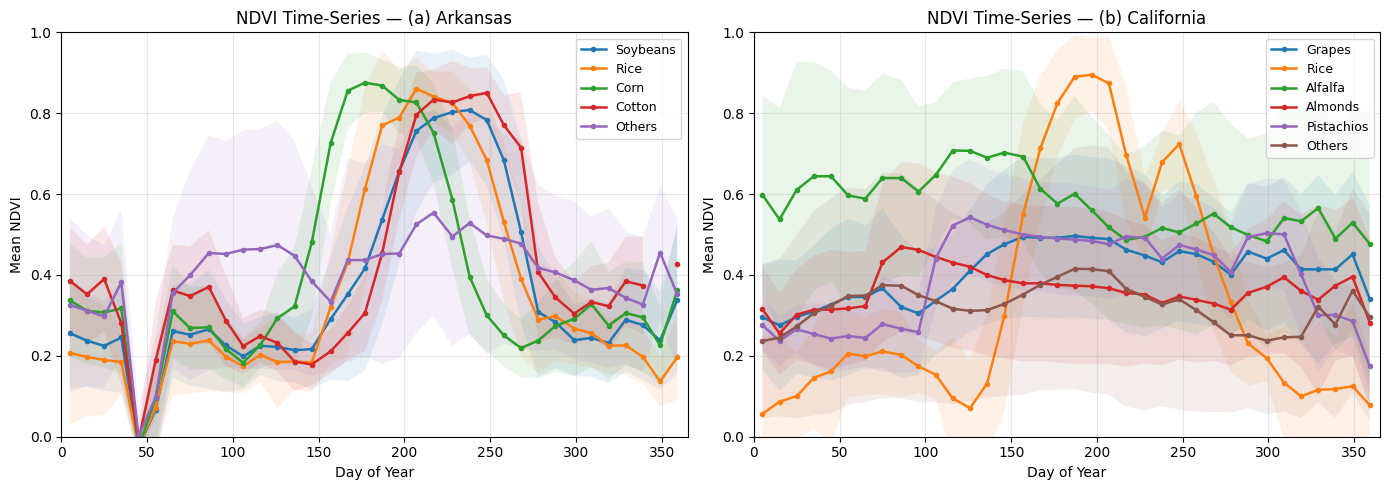

In [4]:
DOY = [int((t - 1) * 365 / N_TIMESTEPS) + 5 for t in range(1, N_TIMESTEPS + 1)]

def compute_ndvi(df):
    nir   = df[[f'NIR_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    red   = df[[f'Red_t{t:02d}' for t in range(1, N_TIMESTEPS+1)]].values.astype('float32')
    valid = df[VALID_COLS].values.astype('float32')
    nir   = np.where(valid == 1, nir, np.nan)
    red   = np.where(valid == 1, red, np.nan)
    return np.clip((nir - red) / (nir + red + 1e-8), -1.0, 1.0)

ndvi_ar = compute_ndvi(df_ar)
ndvi_ca = compute_ndvi(df_ca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ndvi, label_map, title in [
    (axes[0], df_ar, ndvi_ar, AR_LABELS, '(a) Arkansas'),
    (axes[1], df_ca, ndvi_ca, CA_LABELS, '(b) California')
]:
    for code, name in label_map.items():
        m   = df['label'].values == code
        mu  = np.nanmean(ndvi[m], axis=0)
        std = np.nanstd(ndvi[m], axis=0)
        ax.plot(DOY, mu, marker='o', markersize=3, linewidth=1.8, label=name)
        ax.fill_between(DOY, mu - std, mu + std, alpha=0.10)
    ax.set_title(f'NDVI Time-Series — {title}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean NDVI')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

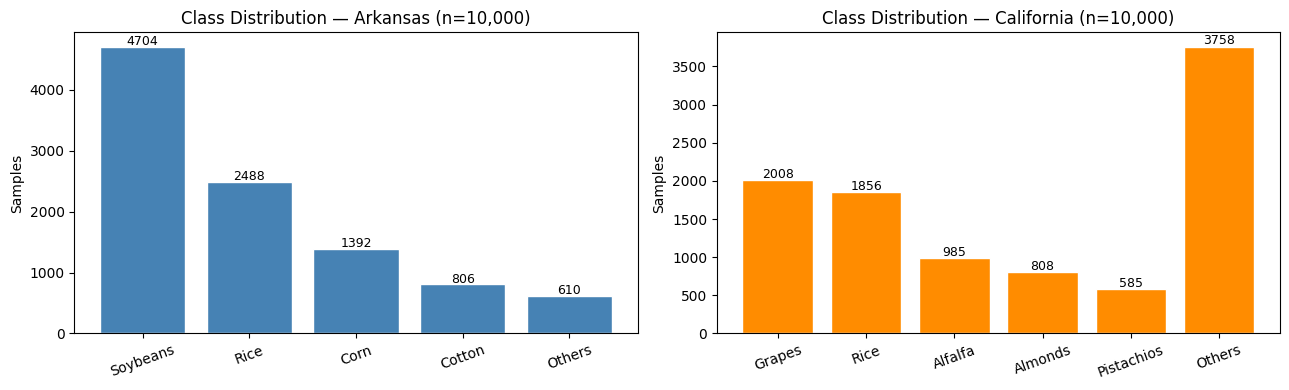

Missing observations — Arkansas: 19.6%  |  California: 13.4%
Zeros = cloud-masked observations. They stay as 0 (ALPE handles them via the mask).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, label_map, color, title in [
    (axes[0], df_ar, AR_LABELS, 'steelblue',  'Arkansas'),
    (axes[1], df_ca, CA_LABELS, 'darkorange', 'California')
]:
    counts = df['label'].value_counts().sort_index()
    names  = [label_map[i] for i in counts.index]
    ax.bar(names, counts.values, color=color, edgecolor='white')
    ax.set_title(f'Class Distribution — {title} (n=10,000)')
    ax.set_ylabel('Samples')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

ar_miss = (1 - df_ar[VALID_COLS].values.mean()) * 100
ca_miss = (1 - df_ca[VALID_COLS].values.mean()) * 100
print(f'Missing observations — Arkansas: {ar_miss:.1f}%  |  California: {ca_miss:.1f}%')
print('Zeros = cloud-masked observations. They stay as 0 (ALPE handles them via the mask).')

## Part 1.4 — Preprocessing

In [6]:
def paper_split(y, n_trainval=300, val_frac=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    tr_idx, va_idx, te_idx = [], [], []
    for cls in np.unique(y):
        idx  = rng.permutation(np.where(y == cls)[0])
        tv   = idx[:n_trainval]
        rest = idx[n_trainval:]
        n_va = int(len(tv) * val_frac)   # 60
        va_idx.extend(tv[:n_va])
        tr_idx.extend(tv[n_va:])         # 240
        te_idx.extend(rest)
    return np.array(tr_idx), np.array(va_idx), np.array(te_idx)


def preprocess(df, label_map, state):
    print(f'\n--- {state} ---')

    # Spectral features (N, 36, 10) — zeros remain as missing markers
    X = df[SPEC_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, N_BANDS)

    # Valid mask (N, 36, 1) — passed to ALPE as Input 2
    mask = df[VALID_COLS].values.astype('float32').reshape(-1, N_TIMESTEPS, 1)

    y = df['label'].values.astype('int32')

    # Min-max normalization — only on valid values, zeros stay 0
    v_min = X[X > 0].min()
    v_max = X.max()
    X     = np.where(X > 0, (X - v_min) / (v_max - v_min + 1e-8), 0.0)

    tr_i, va_i, te_i = paper_split(y)
    print(f'  Train: {len(tr_i)} | Val: {len(va_i)} | Test: {len(te_i)}')

    class_names = [label_map[i] for i in sorted(label_map)]
    return ((X[tr_i], mask[tr_i], y[tr_i]),
            (X[va_i], mask[va_i], y[va_i]),
            (X[te_i], mask[te_i], y[te_i]),
            class_names)


ar_train, ar_val, ar_test, ar_classes = preprocess(df_ar, AR_LABELS, 'Arkansas')
ca_train, ca_val, ca_test, ca_classes = preprocess(df_ca, CA_LABELS, 'California')


--- Arkansas ---
  Train: 1200 | Val: 300 | Test: 8500

--- California ---
  Train: 1440 | Val: 360 | Test: 8200


## Part 1.5 — MCTNet Architecture

In [ ]:
# Sinusoidal positional encoding 
def sinusoidal_pe(T, dm):
    pe  = np.zeros((T, dm), dtype='float32')
    pos = np.arange(T)[:, np.newaxis]
    div = np.exp(np.arange(0, dm, 2) * (-np.log(10000.0) / dm))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

PE_MATRIX = sinusoidal_pe(N_TIMESTEPS, N_BANDS)   # (36, 10)


# ALPE layer — Eq. 3, Fig. 5
class ALPELayer(keras.layers.Layer):
    def __init__(self, dm, **kwargs):
        super().__init__(**kwargs)
        self.pe       = tf.constant(PE_MATRIX[np.newaxis], dtype=tf.float32)
        self.conv     = layers.Conv1D(dm, kernel_size=3, padding='same')
        self.eca_conv = layers.Conv1D(1,  kernel_size=3, padding='same')

    def call(self, mask):
        masked_pe = self.pe * tf.cast(mask, tf.float32)
        x   = self.conv(masked_pe)
        gap = tf.expand_dims(tf.reduce_mean(x, axis=1), axis=-1)
        gap = tf.squeeze(tf.sigmoid(self.eca_conv(gap)), axis=-1)
        return x * tf.expand_dims(gap, axis=1)


# CNN sub-module 
def cnn_sub(x, filters, kernel_size=3):
    shortcut = x if x.shape[-1] == filters else layers.Conv1D(filters, 1, padding='same')(x)
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    x = layers.BatchNormalization()(layers.Conv1D(filters, kernel_size, padding='same')(x))
    return layers.Activation('relu')(layers.Add()([x, shortcut]))


# Transformer sub-module 
def transformer_sub(x, n_heads, pos_enc=None):
    if pos_enc is not None:
        x = layers.Add()([x, pos_enc])
    d    = x.shape[-1]
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(1, d // n_heads))(x, x)
    x    = layers.LayerNormalization()(layers.Add()([x, attn]))
    ff   = layers.Dense(d)(layers.Dense(d, activation='relu')(x))
    return layers.LayerNormalization()(layers.Add()([x, ff]))


# Full MCTNet 
def build_mctnet(n_classes, T=N_TIMESTEPS, C=N_BANDS, n_heads=5):
    inp_feat = keras.Input(shape=(T, C), name='features')   # Input 1
    inp_mask = keras.Input(shape=(T, 1), name='mask')        # Input 2

    alpe_enc = ALPELayer(dm=C, name='alpe')(inp_mask)        # only Stage 1

    # Stage 1: CNN(10) || Trans+ALPE(10) -> Concat(20) -> MaxPool -> (18,20)
    cnn1 = cnn_sub(inp_feat, filters=10)
    tr1  = layers.Conv1D(10, 1, padding='same')(transformer_sub(inp_feat, n_heads, pos_enc=alpe_enc))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn1, tr1]))

    # Stage 2: CNN(20) || Trans(20) -> Concat(40) -> MaxPool -> (9,40)
    cnn2 = cnn_sub(x, filters=20)
    tr2  = layers.Conv1D(20, 1, padding='same')(transformer_sub(x, n_heads))
    x    = layers.MaxPooling1D(pool_size=2, strides=2)(layers.Concatenate()([cnn2, tr2]))

    # Stage 3: CNN(40) || Trans(40) -> Concat(80) -> GlobalMaxPool -> (80,)
    cnn3 = cnn_sub(x, filters=40)
    tr3  = layers.Conv1D(40, 1, padding='same')(transformer_sub(x, n_heads))
    x    = layers.GlobalMaxPooling1D()(layers.Concatenate()([cnn3, tr3]))

    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model([inp_feat, inp_mask], out, name='MCTNet')


demo = build_mctnet(n_classes=5)
demo.summary()
print(f'\nTotal parameters: {demo.count_params():,}')
print('Paper reports ~55,059 parameters for Arkansas.')

Model: "MCTNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mask (InputLayer)   │ (None, 36, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alpe (ALPELayer)    │ (None, 36, 10)    │        314 │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 10)    │          0 │ features[0][0],   │
│                     │                   │            │ alpe[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │        440 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 36, 10)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 10)    │        310 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 10)    │         40 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 10)    │        310 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 36, 10)    │        110 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 36, 10)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 36, 10)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 20)    │          0 │ activation[0][0], │
│ (Concatenate)       │                   │            │ conv1d_4[0][0]  

 Total params: 29,489 (115.19 KB)

 Trainable params: 29,209 (114.10 KB)

 Non-trainable params: 280 (1.09 KB)


Total parameters: 29,489
Paper reports ~55,059 parameters for Arkansas.


## Training

In [8]:
def train_model(model, train_data, val_data, epochs=200, batch_size=32):
    Xtr, mtr, ytr = train_data
    Xva, mva, yva = val_data

    cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
    class_weights = dict(zip(np.unique(ytr), cw))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=8, min_lr=1e-6, verbose=1
        )
    ]

    history = model.fit(
        [Xtr, mtr], ytr,
        validation_data=([Xva, mva], yva),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    return history


def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'],         label='Train')
    ax[0].plot(history.history['val_loss'],     label='Val')
    ax[0].set_title(f'Loss — {title}')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].plot(history.history['accuracy'],     label='Train')
    ax[1].plot(history.history['val_accuracy'], label='Val')
    ax[1].set_title(f'Accuracy — {title}')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_test(model, test_data, class_names, state):
    Xte, mte, yte = test_data
    preds = model.predict([Xte, mte], verbose=0).argmax(axis=1)
    oa    = accuracy_score(yte, preds)
    kappa = cohen_kappa_score(yte, preds)
    f1    = f1_score(yte, preds, average='macro')

    print(f'\n--- {state} Test Results ---')
    print(f'OA={oa:.4f}  Kappa={kappa:.4f}  F1={f1:.4f}')
    print(classification_report(yte, preds, target_names=class_names))

    cm = confusion_matrix(yte, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {state}')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    axes[0].tick_params(axis='x', rotation=30)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'Normalised Confusion Matrix — {state}')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    return oa, kappa, f1

print('Functions defined.')

Functions defined.


## Train — Arkansas

In [9]:
n_ar = len(AR_LABELS)
print(f'Arkansas: {n_ar} classes')
print('Train samples:', len(ar_train[0]))

model_ar = build_mctnet(n_classes=n_ar)
print('Parameters:', model_ar.count_params())

hist_ar = train_model(model_ar, ar_train, ar_val)

Arkansas: 5 classes
Train samples: 1200
Parameters: 29489
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.4750 - loss: 1.4167 - val_accuracy: 0.2233 - val_loss: 1.7867 - learning_rate: 0.0010
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7933 - loss: 0.6660 - val_accuracy: 0.3400 - val_loss: 1.5028 - learning_rate: 0.0010
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8767 - loss: 0.4220 - val_accuracy: 0.5033 - val_loss: 1.2295 - learning_rate: 0.0010
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9000 - loss: 0.3074 - val_accuracy: 0.5967 - val_loss: 1.0191 - learning_rate: 0.0010
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9283 - loss: 0.2420 - val_accuracy: 0.6533 - val_loss: 0.8746 - learning_rate: 0.0010
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9475 - loss: 0.1953 - val_accuracy: 0.7100 - val_loss: 0.7156 - learning_rate: 0.0010
Epoch 7/200
38/38 ━━━━━━━━━━━

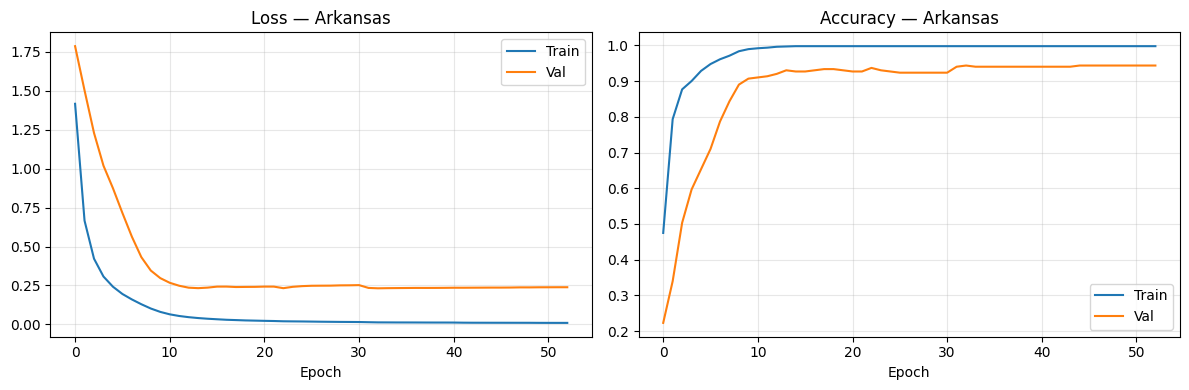


--- Arkansas Test Results ---
OA=0.9368  Kappa=0.9053  F1=0.8848
              precision    recall  f1-score   support

    Soybeans       0.99      0.90      0.94      4404
        Rice       0.98      0.99      0.98      2188
        Corn       0.97      0.98      0.97      1092
      Cotton       0.80      0.97      0.88       506
      Others       0.49      0.94      0.65       310

    accuracy                           0.94      8500
   macro avg       0.85      0.96      0.88      8500
weighted avg       0.96      0.94      0.94      8500



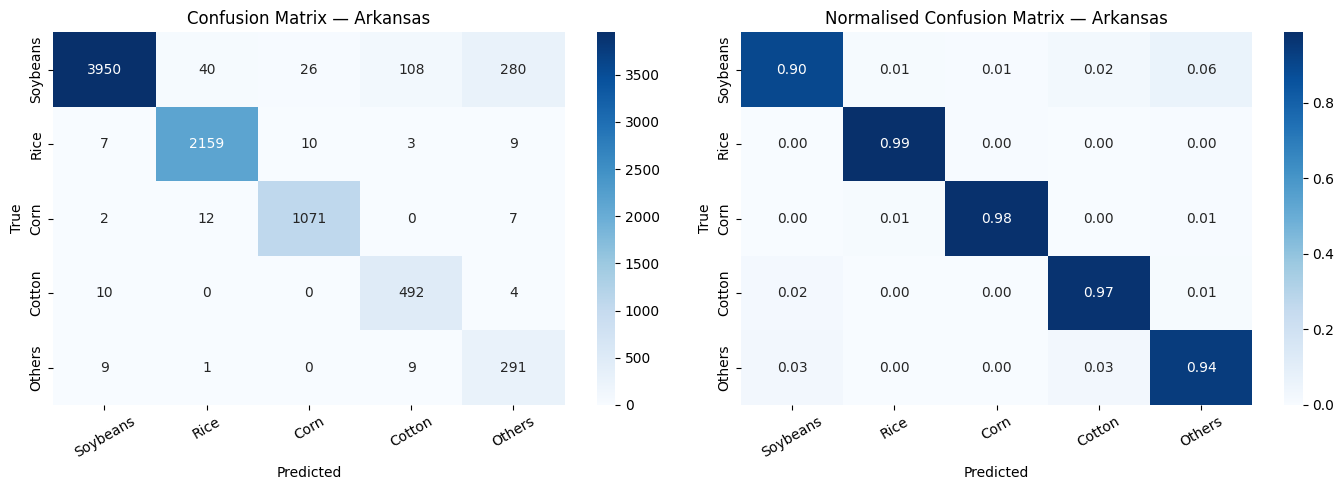

Paper (MCTNet): OA=0.968  Kappa=0.951  F1=0.933
Ours          : OA=0.937  Kappa=0.905  F1=0.885


In [10]:
plot_history(hist_ar, 'Arkansas')
oa_ar, kappa_ar, f1_ar = evaluate_test(model_ar, ar_test, ar_classes, 'Arkansas')

print('Paper (MCTNet): OA=0.968  Kappa=0.951  F1=0.933')
print(f'Ours          : OA={oa_ar:.3f}  Kappa={kappa_ar:.3f}  F1={f1_ar:.3f}')

## Train — California

In [11]:
n_ca = len(CA_LABELS)
print(f'California: {n_ca} classes')
print('Train samples:', len(ca_train[0]))

model_ca = build_mctnet(n_classes=n_ca)
print('Parameters:', model_ca.count_params())

hist_ca = train_model(model_ca, ca_train, ca_val)

California: 6 classes
Train samples: 1440
Parameters: 29570
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.5083 - loss: 1.3747 - val_accuracy: 0.1583 - val_loss: 1.8187 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7181 - loss: 0.7768 - val_accuracy: 0.1694 - val_loss: 1.9182 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8042 - loss: 0.5961 - val_accuracy: 0.1750 - val_loss: 1.9004 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8389 - loss: 0.4972 - val_accuracy: 0.2083 - val_loss: 1.7873 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8625 - loss: 0.4301 - val_accuracy: 0.2750 - val_loss: 1.5531 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8743 - loss: 0.3826 - val_accuracy: 0.4167 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━

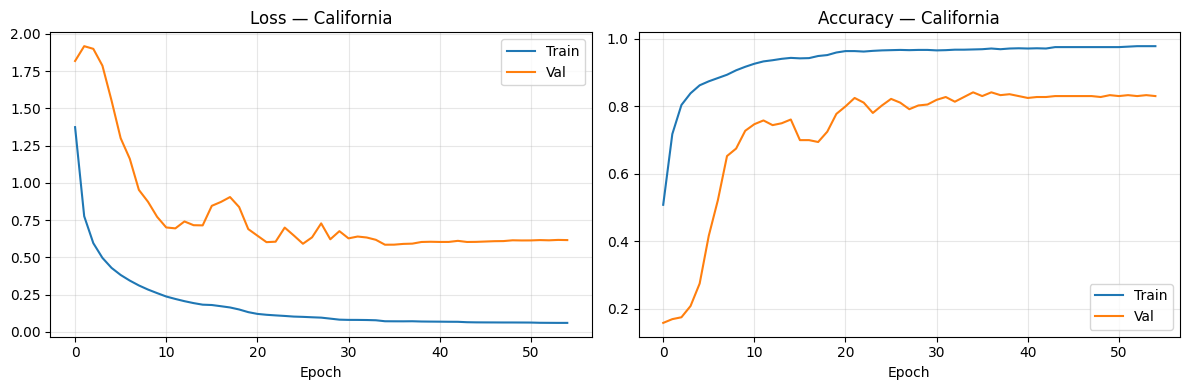


--- California Test Results ---
OA=0.7915  Kappa=0.7296  F1=0.7433
              precision    recall  f1-score   support

      Grapes       0.77      0.79      0.78      1708
        Rice       0.97      0.99      0.98      1556
     Alfalfa       0.82      0.93      0.87       685
     Almonds       0.41      0.70      0.52       508
  Pistachios       0.37      0.91      0.52       285
      Others       0.93      0.68      0.79      3458

    accuracy                           0.79      8200
   macro avg       0.71      0.83      0.74      8200
weighted avg       0.84      0.79      0.80      8200



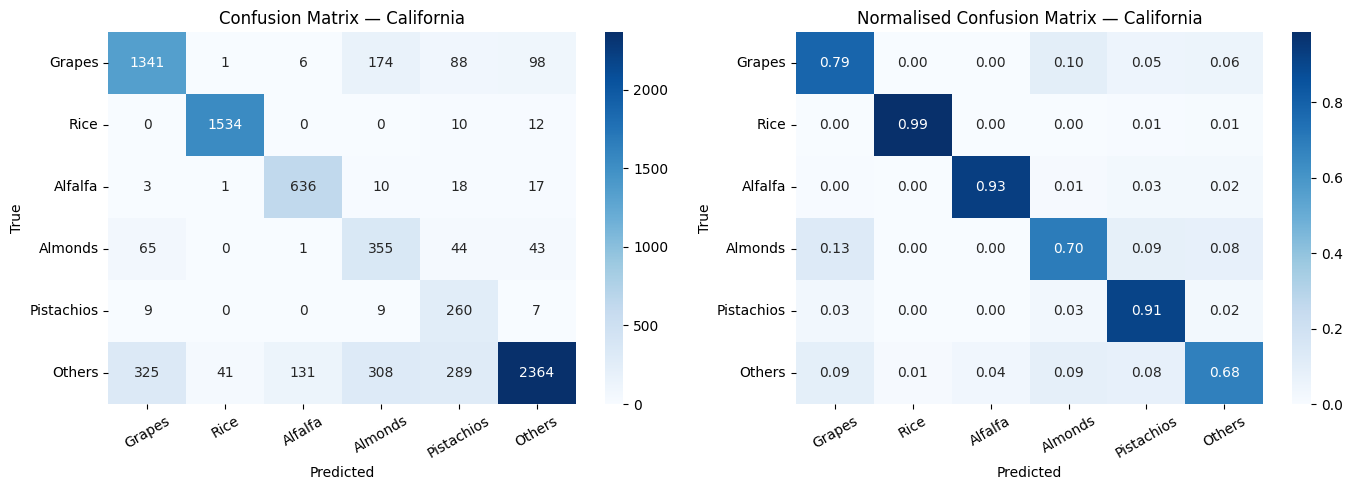

Paper (MCTNet): OA=0.852  Kappa=0.806  F1=0.829
Ours          : OA=0.791  Kappa=0.730  F1=0.743


In [12]:
plot_history(hist_ca, 'California')
oa_ca, kappa_ca, f1_ca = evaluate_test(model_ca, ca_test, ca_classes, 'California')

print('Paper (MCTNet): OA=0.852  Kappa=0.806  F1=0.829')
print(f'Ours          : OA={oa_ca:.3f}  Kappa={kappa_ca:.3f}  F1={f1_ca:.3f}')

## Summary

In [13]:
results = pd.DataFrame({
    'State'         : ['Arkansas', 'California'],
    'OA  (paper)'   : [0.968, 0.852],
    'OA  (ours)'    : [round(oa_ar, 3), round(oa_ca, 3)],
    'Kappa (paper)' : [0.951, 0.806],
    'Kappa (ours)'  : [round(kappa_ar, 3), round(kappa_ca, 3)],
    'F1 (paper)'    : [0.933, 0.829],
    'F1 (ours)'     : [round(f1_ar, 3), round(f1_ca, 3)],
})
print(results.to_string(index=False))

     State  OA  (paper)  OA  (ours)  Kappa (paper)  Kappa (ours)  F1 (paper)  F1 (ours)
  Arkansas        0.968       0.937          0.951         0.905       0.933      0.885
California        0.852       0.791          0.806         0.730       0.829      0.743


In [14]:
model_ar.save(os.path.join(FOLDER, 'mctnet_arkansas.keras'))
model_ca.save(os.path.join(FOLDER, 'mctnet_california.keras'))
print('Models saved.')

Models saved.
